In [1]:
!pip install -q tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import Huber


import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load Dataset

BASE_PATH = '/content/drive/MyDrive/Sanjana/Maintenance_Log_Intelligence/dataset'

train_clean = pd.read_csv(f'{BASE_PATH}/train_processed.csv')
test_clean = pd.read_csv(f'{BASE_PATH}/test_processed.csv')
scaler = joblib.load(f'{BASE_PATH}/scaler.pkl')
y_test = pd.read_csv(f'{BASE_PATH}/CMaps/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

remaining_sensors = [c for c in train_clean.columns if c.startswith('s_')]

In [3]:
# Sequence generation functions

WINDOW_LENGTH = 30

def generate_train_sequences(df, sensor_cols, window_length):
    X, y = [], []
    for unit in df['unit_nr'].unique():
        engine_data = df[df['unit_nr'] == unit].sort_values('time_cycles')
        sensor_values = engine_data[sensor_cols].values
        rul_values = engine_data['RUL'].values
        num_cycles = len(engine_data)
        if num_cycles < window_length:
            continue
        for start in range(num_cycles - window_length + 1):
            end = start + window_length
            X.append(sensor_values[start:end])
            y.append(rul_values[end - 1])
    return np.array(X), np.array(y)

def generate_test_sequences(df, sensor_cols, window_length):
    X = []
    for unit in df['unit_nr'].unique():
        engine_data = df[df['unit_nr'] == unit].sort_values('time_cycles')
        sensor_values = engine_data[sensor_cols].values
        if len(sensor_values) >= window_length:
            window = sensor_values[-window_length:]
        else:
            pad_count = window_length - len(sensor_values)
            padding = np.repeat(sensor_values[0:1], pad_count, axis=0)
            window = np.vstack([padding, sensor_values])
        X.append(window)
    return np.array(X)

In [4]:
# Train/validation split

np.random.seed(42)
all_units = train_clean['unit_nr'].unique()
np.random.shuffle(all_units)

val_size = int(0.15 * len(all_units))
val_units = set(all_units[:val_size])
train_units = set(all_units[val_size:])

train_mask = train_clean['unit_nr'].isin(train_units)
val_mask = train_clean['unit_nr'].isin(val_units)

X_train, y_train = generate_train_sequences(train_clean[train_mask], remaining_sensors, WINDOW_LENGTH)
X_val, y_val = generate_train_sequences(train_clean[val_mask], remaining_sensors, WINDOW_LENGTH)
X_test = generate_test_sequences(test_clean, remaining_sensors, WINDOW_LENGTH)
y_test_true = y_test['RUL'].values

In [5]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"y_test_true shape: {y_test_true.shape}")

X_train shape: (15104, 30, 14)
y_train shape: (15104,)
X_test shape: (100, 30, 14)
y_test shape: (100, 1)
y_test_true shape: (100,)


In [6]:
# Model architecture

n_features = len(remaining_sensors)

model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(WINDOW_LENGTH, n_features)),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='relu')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=Huber(delta=10.0),
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       146,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,481 (1.21 MB)

 Trainable params: 315,713 (1.20 MB)

 Non-trainable params: 768 (3.00 KB)

In [7]:
# Training

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - loss: 562.6350 - mae: 60.9690 - val_loss: 447.7070 - val_mae: 49.6026 - learning_rate: 0.0010
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 198.9154 - mae: 24.3371 - val_loss: 168.9000 - val_mae: 21.5953 - learning_rate: 0.0010
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 160.3823 - mae: 20.4044 - val_loss: 153.2356 - val_mae: 19.4795 - learning_rate: 0.0010
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 174.4022 - mae: 21.8645 - val_loss: 102.0466 - val_mae: 14.1884 - learning_rate: 0.0010
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 171.1499 - mae: 21.5076 - val_loss: 113.7768 - val_mae: 15.6471 - learning_rate: 0.0010
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 143.6530 - mae: 18.6780 - val_loss: 75.0465 - val_mae: 11.0587 - learning_rate: 0.0010
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 134.9649 - mae: 17.7421 - val_loss: 87

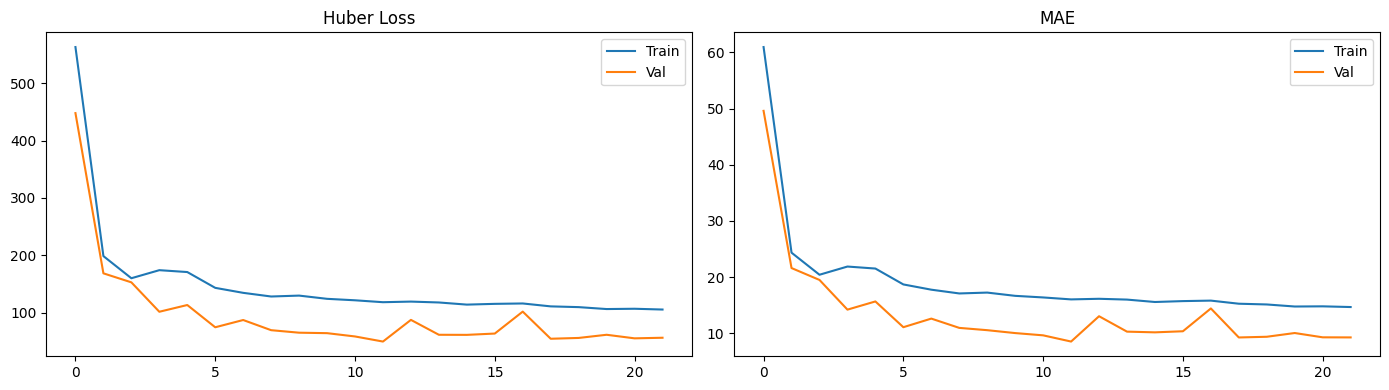

In [8]:
# Training curves

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Huber Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
# Evaluation

lstm_preds = model.predict(X_test).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test_true, lstm_preds))
lstm_mae = mean_absolute_error(y_test_true, lstm_preds)

def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(score)

lstm_score = nasa_score(y_test_true, lstm_preds)

with open(f'{BASE_PATH}/rf_and_xgb_results_metadata.json', 'r') as f:
    baseline_results = json.load(f)['baseline_results']

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Bi-LSTM'],
    'RMSE': [baseline_results['rf_rmse'], baseline_results['xgb_rmse'], lstm_rmse],
    'MAE': [baseline_results.get('rf_mae'), baseline_results.get('xgb_mae'), lstm_mae],
    'NASA_Score': [baseline_results['rf_nasa_score'], baseline_results['xgb_nasa_score'], lstm_score]
})
comparison

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,Model,RMSE,MAE,NASA_Score
0,Random Forest,18.205683,13.304478,922.323741
1,XGBoost,17.750022,12.964081,840.725815
2,Bi-LSTM,15.817503,11.498095,527.733977


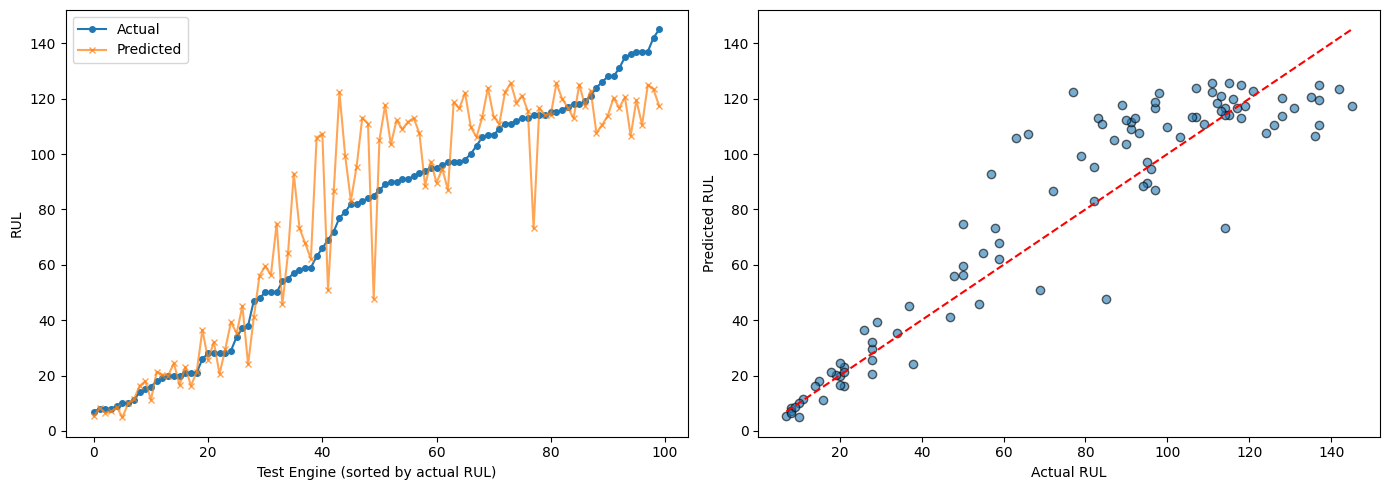

In [11]:
# Prediction visualization

sort_idx = np.argsort(y_test_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(y_test_true[sort_idx], label='Actual', marker='o', markersize=4)
axes[0].plot(lstm_preds[sort_idx], label='Predicted', marker='x', markersize=4, alpha=0.7)
axes[0].set_xlabel('Test Engine (sorted by actual RUL)')
axes[0].set_ylabel('RUL')
axes[0].legend()

axes[1].scatter(y_test_true, lstm_preds, alpha=0.6, edgecolor='black')
axes[1].plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()], 'r--')
axes[1].set_xlabel('Actual RUL')
axes[1].set_ylabel('Predicted RUL')
plt.tight_layout()
plt.show()

In [12]:
# Save artifacts

model.save(f'{BASE_PATH}/bilstm_model.h5')
comparison.to_csv(f'{BASE_PATH}/model_comparison.csv', index=False)

metadata = {
    'window_length': WINDOW_LENGTH,
    'architecture': 'Bidirectional LSTM (128 -> 64) + Dense',
    'loss_function': 'Huber(delta=10.0)',
    'results': {'rmse': float(lstm_rmse), 'mae': float(lstm_mae), 'nasa_score': float(lstm_score)}
}
with open(f'{BASE_PATH}/lstm_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)